# Main figure 2: central spectroscopy result

This notebook combines the measured two-dimensional echo-root-Lorentzian amplitude sweep with selected one-dimensional experimental slices and cached two-level simulation curves. Experimental data and simulation are labeled separately. Because the cached simulation was generated with a different parameter set, the slices are normalized independently and are a shape comparison rather than a parameter-free quantitative agreement test.

In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

from echospec.figures import FigureVariant, apply_figure_style, save_figure

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)

EXPERIMENT_PATH = PROJECT_ROOT / 'ips_plots/data/lorentzian_echo/echo_lorentzian_12-33-44-667799_data_bundle.npz'
SIMULATION_PATH = PROJECT_ROOT / 'data/2d_sweep/echo_lorentzian.npz'
SELECTED_AMPLITUDES_MHZ = [8.5, 25.0, 50.0]
print(EXPERIMENT_PATH)
print(SIMULATION_PATH)

/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/ips_plots/data/lorentzian_echo/echo_lorentzian_12-33-44-667799_data_bundle.npz
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/2d_sweep/echo_lorentzian.npz


In [2]:
def load_experimental_bundle(path):
    with np.load(path, allow_pickle=True) as bundle:
        parameters = json.loads(bundle['parameters.json'].item())
        qubits = json.loads(bundle['profile__qubits.json'].item())['qubits']
        pulses = json.loads(bundle['profile__pulses.json'].item())['pulses']
        qubit = str(bundle['data__qubit'][0])
        x180_name = qubits[qubit]['operations']['x180']
        pi_pulse = pulses[qubit][x180_name]
        amp_prefactor = np.asarray(bundle['data__amp_prefactor'], dtype=float)
        pi_rabi_mhz = 1000 / (2 * pi_pulse['length_ns'])
        rabi_mhz = amp_prefactor / pi_pulse['amplitude'] * pi_rabi_mhz
        return {
            'detuning_mhz': np.asarray(bundle['data__detuning'], dtype=float) / 1e6,
            'rabi_mhz': rabi_mhz,
            'state': np.asarray(bundle['data__state'][0], dtype=float),
            'qubit': qubit,
            'parameters': parameters,
        }

def normalize_trace(y):
    y = np.asarray(y, dtype=float)
    scale = np.nanmax(y) - np.nanmin(y)
    return (y - np.nanmin(y)) / scale if scale > 0 else np.full_like(y, np.nan)

experiment = load_experimental_bundle(EXPERIMENT_PATH)
with np.load(SIMULATION_PATH) as cached:
    simulation = {
        'detuning_mhz': cached['detunings'] / (2 * np.pi * 1e6),
        'rabi_mhz': cached['amplitudes'] / (2 * np.pi * 1e6),
        'state': cached['states'],
    }

print(f"Experimental map: {experiment['state'].shape}, qubit {experiment['qubit']}")
print(f"Simulation map: {simulation['state'].shape}")
print(experiment['parameters'])

Experimental map: (1001, 100), qubit q1
Simulation map: (101, 101)
{'multiplexed': False, 'use_state_discrimination': True, 'reset_type': 'active', 'qubits': None, 'num_shots': 40, 'operation': 'lorentzian', 'pulse_shape': 'root_lorentzian', 'lorentzian_length_in_ns': 10000, 'waveform_template_length_in_ns': 10000, 'lorentzian_tau_in_ns': 8.0, 'lorentzian_peak_amplitude': 0.2, 'cutoff': 0.005, 'echo': True, 'min_amp_factor': 0.0, 'max_amp_factor': 1.0, 'amp_factor_step': 0.01, 'frequency_span_in_mhz': 1, 'frequency_step_in_mhz': 0.001, 'simulate': False, 'simulation_duration_ns': 50000, 'use_waveform_report': True, 'timeout': 120, 'load_data_id': None}


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/02_central_spectroscopy.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/02_central_spectroscopy.svg')]

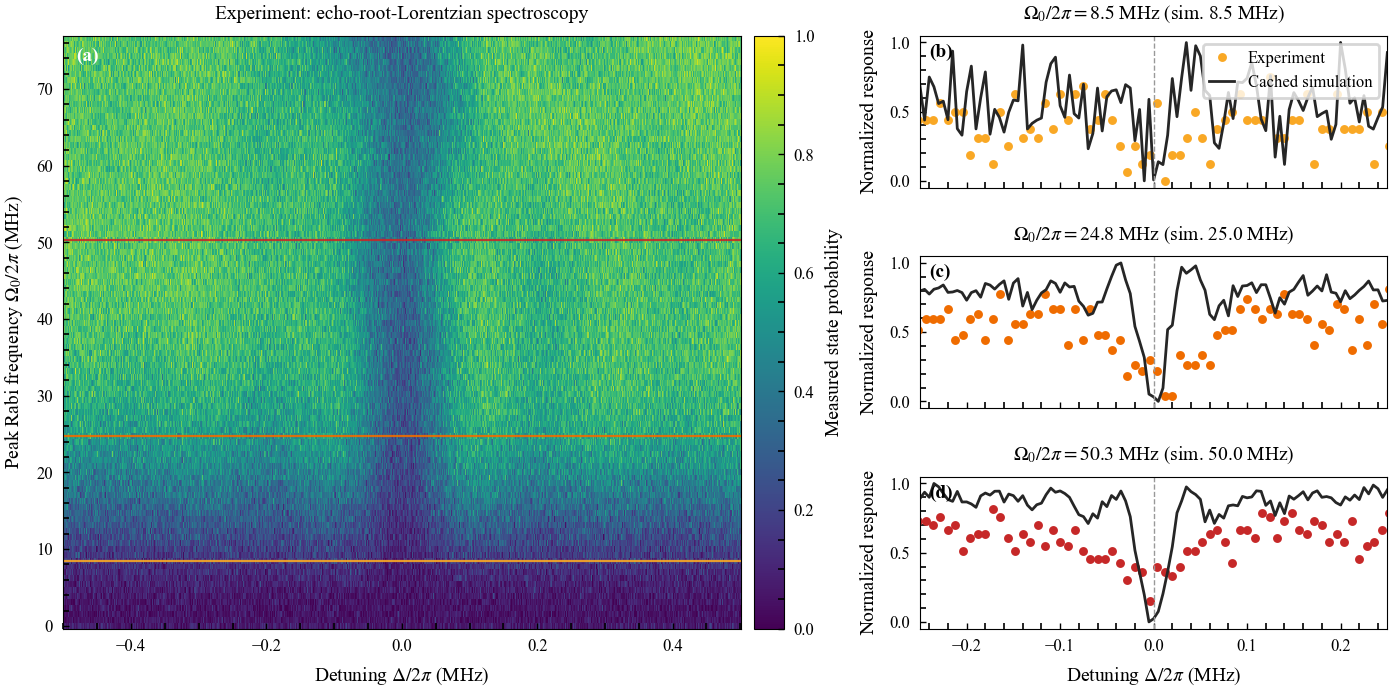

In [3]:
fig = plt.figure(figsize=(7.0, 3.5), constrained_layout=True)
grid = GridSpec(3, 2, figure=fig, width_ratios=[1.45, 1.0])
ax_map = fig.add_subplot(grid[:, 0])
slice_axes = [fig.add_subplot(grid[i, 1]) for i in range(3)]

image = ax_map.pcolormesh(
    experiment['detuning_mhz'],
    experiment['rabi_mhz'],
    experiment['state'].T,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=1,
    rasterized=True,
)
ax_map.set(
    xlabel=r'Detuning $\Delta/2\pi$ (MHz)',
    ylabel=r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)',
    title='Experiment: echo-root-Lorentzian spectroscopy',
)
colorbar = fig.colorbar(image, ax=ax_map, pad=0.02)
colorbar.set_label('Measured state probability')

colors = ['#f9a825', '#ef6c00', '#c62828']
for color, target_amp, ax in zip(colors, SELECTED_AMPLITUDES_MHZ, slice_axes):
    exp_index = int(np.argmin(np.abs(experiment['rabi_mhz'] - target_amp)))
    sim_index = int(np.argmin(np.abs(simulation['rabi_mhz'] - target_amp)))
    exp_amp = experiment['rabi_mhz'][exp_index]
    sim_amp = simulation['rabi_mhz'][sim_index]
    exp_trace = normalize_trace(experiment['state'][:, exp_index])
    sim_trace = normalize_trace(simulation['state'][sim_index])

    ax_map.axhline(exp_amp, color=color, lw=0.8, alpha=0.9)
    ax.plot(experiment['detuning_mhz'][::8], exp_trace[::8], 'o', ms=2.2, color=color, label='Experiment')
    ax.plot(simulation['detuning_mhz'], sim_trace, color='0.15', lw=1.0, label='Cached simulation')
    ax.axvline(0, color='0.6', ls='--', lw=0.5)
    ax.set_xlim(-0.25, 0.25)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Normalized response')
    ax.set_title(rf'$\Omega_0/2\pi={exp_amp:.1f}$ MHz (sim. {sim_amp:.1f} MHz)')

slice_axes[0].legend(loc='upper right')
slice_axes[-1].set_xlabel(r'Detuning $\Delta/2\pi$ (MHz)')
for ax in slice_axes[:-1]:
    ax.tick_params(labelbottom=False)

ax_map.text(0.02, 0.98, '(a)', transform=ax_map.transAxes, ha='left', va='top', color='white', fontweight='bold')
for label, ax in zip(['(b)', '(c)', '(d)'], slice_axes):
    ax.text(0.02, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontweight='bold')

saved = save_figure(fig, '02_central_spectroscopy', variant=VARIANT)
saved

### Provenance and interpretation

- The map and markers are hardware data from the selected saved bundle.
- The solid curves are cached two-level simulations from `data/2d_sweep/echo_lorentzian.npz`.
- Each experimental and simulated slice is independently min-max normalized because the cached simulation does not use the exact experimental parameter set. A final quantitative comparison should regenerate the simulation with the measured pulse length, cutoff, $T_1$, $T_2$, amplitude calibration, and readout mapping.